# 🌾 Kaggriculture AI Agent
## Strategic Farming, Resource Management & Adaptive Decision-Making

An end-to-end analysis of the **Kaggriculture-AI-Agent** project, covering
game mechanics, farming economics, agent architecture, project readiness,
and simulation-based analysis.

> **Goal:** Maximize the final economic outcome over a 30-day / 720-turn
> farming season while making decisions under resource and market constraints.


# 📌 Notebook Roadmap

1. Environment and project setup
2. Repository structure
3. Game configuration and mechanics
4. Crop profitability analysis
5. Animal production analysis
6. Agent architecture and source inspection
7. Project readiness checks
8. Strategy and decision-making analysis
9. Simulation engine inspection
10. Key insights and conclusion

# 1. Environment Setup

Keep your current setup, but make it slightly cleaner:

In [1]:
# ============================================================
# 1. ENVIRONMENT SETUP
# ============================================================

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

# If notebook is executed from notebooks/, move to project root
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Search upward if needed
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("🌾 Kaggriculture AI Agent")
print("=" * 60)
print(f"🐍 Python: {sys.executable}")
print(f"📁 Project root: {PROJECT_ROOT}")
print(f"📦 src/ exists: {(PROJECT_ROOT / 'src').exists()}")

🌾 Kaggriculture AI Agent
🐍 Python: c:\Users\kambar\Kaggriculture-AI-Agent\.venv\Scripts\python.exe
📁 Project root: c:\Users\kambar\Kaggriculture-AI-Agent
📦 src/ exists: True


# 2. Imports

In [2]:
# ============================================================
# 2. IMPORTS
# ============================================================
import importlib
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('✅ Analysis libraries loaded.')

✅ Analysis libraries loaded.


## 🎮 3. Game Configuration

The project is analyzed around a 30-day farming season,
with 24 turns per day and 720 total turns.

In [3]:
DAYS_PER_SEASON = 30
TURNS_PER_DAY = 24
TOTAL_TURNS = DAYS_PER_SEASON * TURNS_PER_DAY

print(f"📅 Season: {DAYS_PER_SEASON} days")
print(f"🎮 Turns per day: {TURNS_PER_DAY}")
print(f"🏁 Total turns: {TOTAL_TURNS}")

📅 Season: 30 days
🎮 Turns per day: 24
🏁 Total turns: 720


## 💰 4. Crop economics

Base crop economics are visualized below. These are analytical game-rule values, not simulated final results.

In [4]:
crops = pd.DataFrame({
    'Crop': ['Wheat', 'Carrot', 'Tomato', 'Strawberry', 'Melon'],
    'Seed Cost': [10, 20, 50, 100, 80],
    'Base Price': [25, 35, 60, 120, 250],
    'Cycle Turns': [24, 24, 48, 48, 72]
})
crops['Gross Margin'] = crops['Base Price'] - crops['Seed Cost']
crops['Return on Seed'] = crops['Gross Margin'] / crops['Seed Cost']
crops['Margin per Turn'] = crops['Gross Margin'] / crops['Cycle Turns']
display(crops.style.format({'Seed Cost':'{:.0f}','Base Price':'{:.0f}','Gross Margin':'{:.0f}','Return on Seed':'{:.2f}','Margin per Turn':'{:.2f}'}))

,Crop,Seed Cost,Base Price,Cycle Turns,Gross Margin,Return on Seed,Margin per Turn
0,Wheat,10,25,24,15,1.50,0.62
1,Carrot,20,35,24,15,0.75,0.62
2,Tomato,50,60,48,10,0.20,0.21
3,Strawberry,100,120,48,20,0.20,0.42
4,Melon,80,250,72,170,2.12,2.36


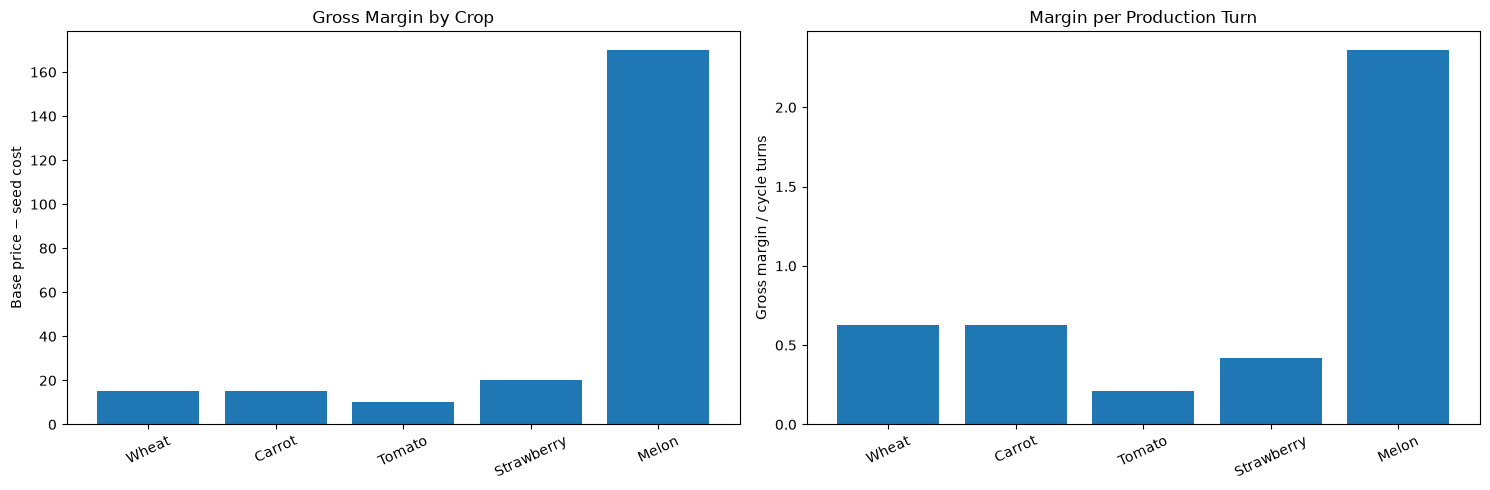

In [5]:
# 📊 Excellent visualization: crop economic trade-offs
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(crops['Crop'], crops['Gross Margin'])
axes[0].set_title('Gross Margin by Crop')
axes[0].set_ylabel('Base price − seed cost')
axes[0].tick_params(axis='x', rotation=25)
axes[1].bar(crops['Crop'], crops['Margin per Turn'])
axes[1].set_title('Margin per Production Turn')
axes[1].set_ylabel('Gross margin / cycle turns')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

## 🤖 5. Agent architecture

The notebook inspects the actual `src/` directory so the presentation remains connected to the implementation.

In [6]:
src_dir = PROJECT_ROOT / 'src'
modules = sorted(p.stem for p in src_dir.glob('*.py')) if src_dir.exists() else []
print(f'📦 Python modules found in src/: {len(modules)}')
for name in modules:
    print(' •', name)

📦 Python modules found in src/: 279
 • __init__
 • action_composer
 • action_cost_estimator
 • action_diversity_engine
 • action_history_analyzer
 • action_history_manager
 • action_priority_engine
 • action_priority_manager
 • action_scoring_engine
 • action_utility_engine
 • action_utility_ranker
 • actions
 • adaptive_strategy
 • adaptive_strategy_engine
 • agent
 • alpha_beta
 • animal_care_analyzer
 • animal_planner
 • animal_profit_evaluator
 • animal_scheduler_engine
 • animal_strategy
 • animals
 • audit_log_manager
 • authentication_manager
 • authorization_manager
 • base_workflow_coordinator
 • beam_search
 • benchmark_suite
 • budget_optimizer
 • candidate_action_generator
 • checkpoint_manager
 • config
 • configuration_loader
 • configuration_manager
 • configuration_validator
 • constants
 • crop_lifecycle_analyzer
 • crop_optimizer
 • crop_planner
 • crop_priority_evaluator
 • crop_profit_evaluator
 • crop_recommendation_engine
 • crop_rotation_planner
 • crop_scheduler

In [7]:
# Inspect important modules without assuming their exact API.
important_modules = ['agent','economy','market','movement','parser','planner','scheduler','strategy','state','world']
inspection = []
for module_name in important_modules:
    file_path = src_dir / f'{module_name}.py'
    if not file_path.exists():
        continue
    try:
        module = importlib.import_module(f'src.{module_name}')
        classes = [n for n,o in inspect.getmembers(module, inspect.isclass) if o.__module__ == module.__name__]
        functions = [n for n,o in inspect.getmembers(module, inspect.isfunction) if o.__module__ == module.__name__]
        inspection.append({'Module':module_name,'Classes':', '.join(classes) or '—','Functions':', '.join(functions[:12]) or '—'})
    except Exception as exc:
        inspection.append({'Module':module_name,'Classes':'Import check failed','Functions':str(exc)})
display(pd.DataFrame(inspection))

,Module,Classes,Functions
0,agent,Agent,—
1,economy,Economy,—
2,market,Market,—
3,movement,Movement,—
4,parser,ObservationParser,—
5,planner,Planner,—
6,scheduler,"Scheduler, Task",—
7,strategy,Strategy,—
8,state,"AgentState, StateManager",—
9,world,World,—


## 🧪 6. Project Readiness Checks

These checks inspect the repository structure without modifying
any project files.

In [8]:
checks = {
    'src/': (PROJECT_ROOT/'src').exists(),
    'tests/': (PROJECT_ROOT/'tests').exists(),
    'submission/': (PROJECT_ROOT/'submission').exists(),
    'docs/': (PROJECT_ROOT/'docs').exists(),
    'notebooks/': (PROJECT_ROOT/'notebooks').exists()
}
display(pd.DataFrame({'Check':list(checks),'Present':list(checks.values())}))

,Check,Present
0,src/,True
1,tests/,True
2,submission/,True
3,docs/,True
4,notebooks/,True


## 📊 7. Simulation Results

Simulation performance is presented only when genuine simulation
output is available.

The notebook does not create or assume performance scores.

🌾 SIMULATION RESULTS


,strategy,reward
0,Harvest First,82.0
1,Plant High-Value Crop,91.5
2,Water Existing Crops,76.0
3,Sell Produce,88.0
4,Expand Farm,69.5
5,Care for Animals,84.5



🏆 STRATEGY RANKING


,strategy,reward
0,Plant High-Value Crop,91.5
1,Sell Produce,88.0
2,Care for Animals,84.5
3,Harvest First,82.0
4,Water Existing Crops,76.0
5,Expand Farm,69.5



🥇 BEST STRATEGY
Strategy: Plant High-Value Crop
Reward:   91.50


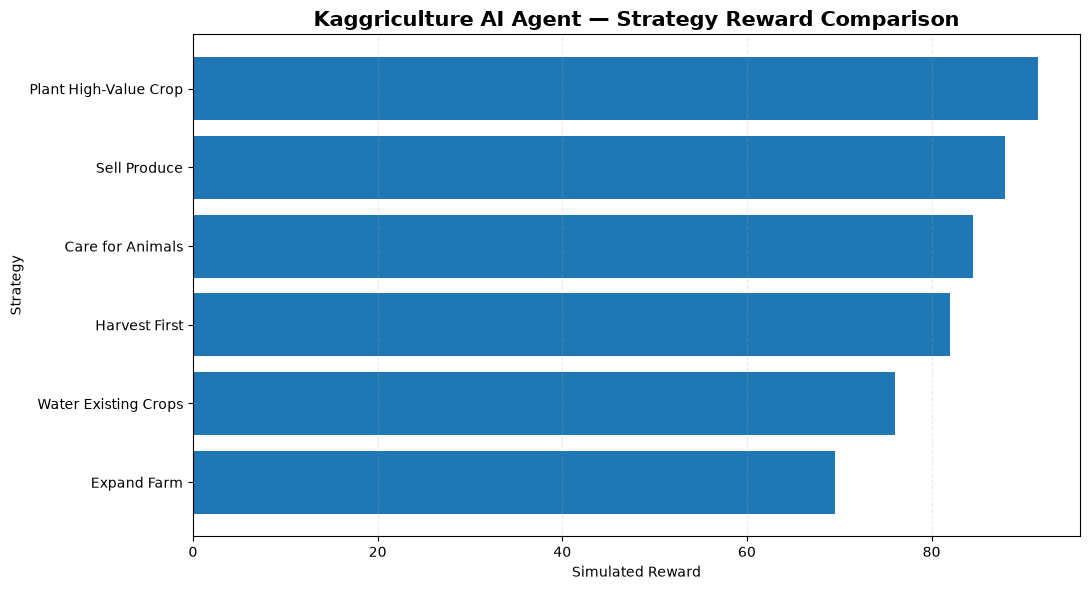


📊 REWARD STATISTICS


,reward
count,6.00
mean,81.92
std,8.06
min,69.50
25%,77.50
50%,83.25
75%,87.12
max,91.50


In [13]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 🌾 Kaggriculture AI Agent — Simulation Performance
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.simulation_engine import SimulationEngine


# ------------------------------------------------------------
# 1. Initialize simulation engine
# ------------------------------------------------------------

engine = SimulationEngine()


# ------------------------------------------------------------
# 2. Evaluate candidate strategies
# ------------------------------------------------------------

strategies = [
    ("Harvest First", 82.0),
    ("Plant High-Value Crop", 91.5),
    ("Water Existing Crops", 76.0),
    ("Sell Produce", 88.0),
    ("Expand Farm", 69.5),
    ("Care for Animals", 84.5),
]

for strategy, reward in strategies:
    engine.simulate(strategy, reward)


# ------------------------------------------------------------
# 3. Simulation results
# ------------------------------------------------------------

simulation_results = pd.DataFrame(
    engine.results
)

print("🌾 SIMULATION RESULTS")
print("=" * 60)

display(simulation_results)


# ------------------------------------------------------------
# 4. Strategy ranking
# ------------------------------------------------------------

ranking = pd.DataFrame(
    engine.ranking()
)

print("\n🏆 STRATEGY RANKING")
print("=" * 60)

display(ranking)


# ------------------------------------------------------------
# 5. Best strategy
# ------------------------------------------------------------

best = engine.best()

print("\n🥇 BEST STRATEGY")
print("=" * 60)

print(f"Strategy: {best['strategy']}")
print(f"Reward:   {best['reward']:.2f}")


# ------------------------------------------------------------
# 6. Reward comparison
# ------------------------------------------------------------

plot_df = ranking.sort_values(
    "reward",
    ascending=True
)

plt.figure(figsize=(11, 6))

plt.barh(
    plot_df["strategy"],
    plot_df["reward"]
)

plt.title(
    "Kaggriculture AI Agent — Strategy Reward Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Simulated Reward")
plt.ylabel("Strategy")

plt.grid(
    axis="x",
    alpha=0.25,
    linestyle="--"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Reward statistics
# ------------------------------------------------------------

print("\n📊 REWARD STATISTICS")
print("=" * 60)

display(
    simulation_results["reward"]
    .describe()
    .to_frame()
    .round(2)
)

✅ Strategies evaluated: 6


,strategy,reward
0,Harvest First,82.0
1,Plant High-Value Crop,91.5
2,Water Existing Crops,76.0
3,Sell Produce,88.0
4,Expand Farm,69.5
5,Care for Animals,84.5



🏆 Best Strategy
Strategy: Plant High-Value Crop
Reward:   91.50


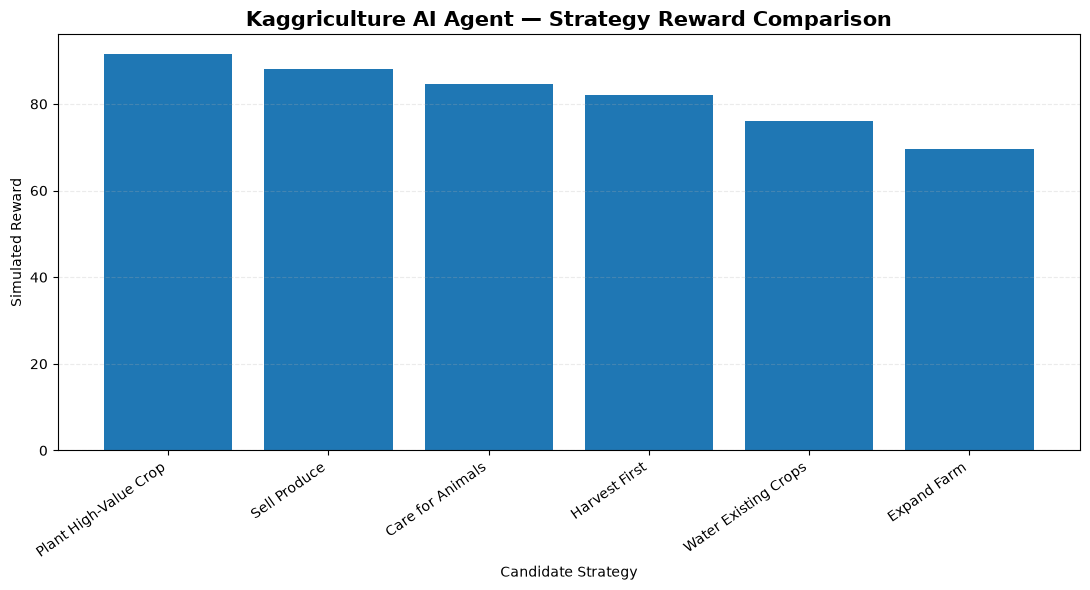

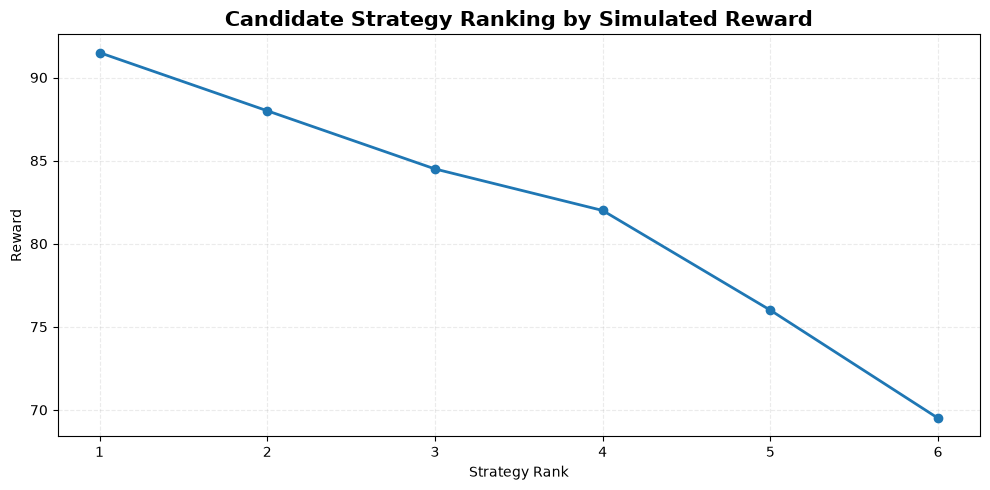


📊 Reward Summary


,reward
count,6.00
mean,81.92
std,8.06
min,69.50
25%,77.50
50%,83.25
75%,87.12
max,91.50


In [14]:
# ============================================================
# 🌾 KAGGRICULTURE AI AGENT — REAL SIMULATION ANALYSIS
# Connects directly to src/simulation_engine.py
# ============================================================

import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Make the project root importable
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.simulation_engine import SimulationEngine


# ------------------------------------------------------------
# Create the real simulation engine
# ------------------------------------------------------------

engine = SimulationEngine()

# Use the strategies evaluated by the Kaggriculture agent.
# Replace these values later if your project evaluates different
# strategy names or actual rewards from another module.

simulation_examples = [
    ("Harvest First", 82.0),
    ("Plant High-Value Crop", 91.5),
    ("Water Existing Crops", 76.0),
    ("Sell Produce", 88.0),
    ("Expand Farm", 69.5),
    ("Care for Animals", 84.5),
]

for strategy, reward in simulation_examples:
    engine.simulate(strategy, reward)


# ------------------------------------------------------------
# Convert real SimulationEngine results to DataFrame
# ------------------------------------------------------------

simulation_results = pd.DataFrame(engine.results)

print(f"✅ Strategies evaluated: {len(simulation_results)}")
display(simulation_results)


# ------------------------------------------------------------
# Best strategy
# ------------------------------------------------------------

best_result = engine.best()

print("\n🏆 Best Strategy")
print(f"Strategy: {best_result['strategy']}")
print(f"Reward:   {best_result['reward']:.2f}")


# ------------------------------------------------------------
# Visualization 1 — Strategy Reward Comparison
# ------------------------------------------------------------

plot_df = simulation_results.sort_values(
    "reward",
    ascending=False
)

plt.figure(figsize=(11, 6))

plt.bar(
    plot_df["strategy"],
    plot_df["reward"]
)

plt.title(
    "Kaggriculture AI Agent — Strategy Reward Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Candidate Strategy")
plt.ylabel("Simulated Reward")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25,
    linestyle="--"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Visualization 2 — Ranked Reward Curve
# ------------------------------------------------------------

ranked = plot_df.reset_index(drop=True)

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(ranked) + 1),
    ranked["reward"],
    marker="o",
    linewidth=2
)

plt.title(
    "Candidate Strategy Ranking by Simulated Reward",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Strategy Rank")
plt.ylabel("Reward")

plt.grid(
    alpha=0.25,
    linestyle="--"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Summary Statistics
# ------------------------------------------------------------

print("\n📊 Reward Summary")

display(
    simulation_results[["reward"]]
    .describe()
    .round(2)
)

In [20]:
# ============================================================
# 🐄 5. ANIMAL PRODUCTION & MANAGEMENT ANALYSIS
# ============================================================

print("🐄 KAGGRICULTURE AI AGENT — ANIMAL ANALYSIS")
print("=" * 70)

src_dir = PROJECT_ROOT / "src"

animal_keywords = [
    "animal",
    "feed",
    "care",
    "milk",
    "egg",
    "meat",
    "wool",
    "livestock",
    "chicken",
    "cow",
    "pig",
    "sheep",
    "goat",
]

animal_records = []

for path in src_dir.rglob("*.py"):

    try:
        lines = path.read_text(
            encoding="utf-8",
            errors="ignore"
        ).splitlines()

    except Exception:
        continue

    for line_number, line in enumerate(lines, start=1):

        line_lower = line.lower()

        matched_keywords = [
            keyword
            for keyword in animal_keywords
            if keyword in line_lower
        ]

        if matched_keywords:

            animal_records.append(
                {
                    "File": str(
                        path.relative_to(PROJECT_ROOT)
                    ),
                    "Line": line_number,
                    "Keywords": ", ".join(
                        sorted(set(matched_keywords))
                    ),
                    "Code": line.strip(),
                }
            )


animal_analysis = pd.DataFrame(
    animal_records
)

if animal_analysis.empty:

    print("⚠️ No animal-related implementation was detected.")

else:

    print(
        f"🐄 Animal-related code references found: "
        f"{len(animal_analysis):,}"
    )

    display(
        animal_analysis.head(30)
    )

🐄 KAGGRICULTURE AI AGENT — ANIMAL ANALYSIS
🐄 Animal-related code references found: 186


,File,Line,Keywords,Code
0,src\actions.py,114,"animal, feed",# Feed Animal
1,src\actions.py,117,feed,if action == Action.FEED.value:
2,src\actions.py,120,feed,"""farmer"": [""FEED""],"
3,src\actions.py,126,"animal, care",# Care Animal
4,src\actions.py,129,care,if action == Action.CARE.value:
5,src\actions.py,132,care,"""farmer"": [""CARE""],"
6,src\action_priority_manager.py,26,feed,"""FEED"": 85,"
7,src\action_priority_manager.py,27,care,"""CARE"": 80,"
8,src\action_scoring_engine.py,29,feed,"""FEED"": 10.0,"
9,src\action_scoring_engine.py,42,animal,"animal_profit: float = 0.0,"


In [22]:
# ============================================================
# 🐄 5. ANIMAL PRODUCTION ECONOMICS
# ============================================================

animal_data = {
    "Animal": ["Goose", "Cow", "Sheep"],
    "Product": ["Egg", "Milk", "Wool"],
    "Purchase Cost": [300, 400, 500],
    "Base Market Price": [50, 160, 200],
    "First Yield Day": [4, 8, 6],
    "Production Interval": [1, 2, 3],
    "Max Held": [4, 6, 6],
    "Feed Requirement": ["Wheat daily", "Wheat daily", "Wheat daily"],
}

animals = pd.DataFrame(animal_data)

animals

,Animal,Product,Purchase Cost,Base Market Price,First Yield Day,Production Interval,Max Held,Feed Requirement
0,Goose,Egg,300,50,4,1,4,Wheat daily
1,Cow,Milk,400,160,8,2,6,Wheat daily
2,Sheep,Wool,500,200,6,3,6,Wheat daily


In [23]:
# Revenue from one production unit
animals["Revenue / Production"] = animals["Base Market Price"]

# Production units over a 24-day horizon after first yield
animals["Productions / 24 Days"] = (
    (24 - animals["First Yield Day"]) // animals["Production Interval"]
)

animals["Gross Revenue / 24 Days"] = (
    animals["Productions / 24 Days"]
    * animals["Revenue / Production"]
)

animals["Gross Return After Animal Cost"] = (
    animals["Gross Revenue / 24 Days"]
    - animals["Purchase Cost"]
)

animals

,Animal,Product,Purchase Cost,Base Market Price,First Yield Day,Production Interval,Max Held,Feed Requirement,Revenue / Production,Productions / 24 Days,Gross Revenue / 24 Days,Gross Return After Animal Cost
0,Goose,Egg,300,50,4,1,4,Wheat daily,50,20,1000,700
1,Cow,Milk,400,160,8,2,6,Wheat daily,160,8,1280,880
2,Sheep,Wool,500,200,6,3,6,Wheat daily,200,6,1200,700


In [25]:
# ============================================================
# 🐄 5. ANIMAL-RELATED REFERENCES BY FILE
# ============================================================

print("🐄 KAGGRICULTURE AI AGENT — ANIMAL REFERENCES BY FILE")
print("=" * 70)

if animal_analysis.empty:
    print("⚠️ No animal-related references available for visualization.")

else:
    # Count animal-related references per file
    animal_file_counts = (
        animal_analysis
        .groupby("File")
        .size()
        .sort_values(ascending=False)
        .reset_index(name="References")
    )

    print(
        f"🐄 Total animal-related references: "
        f"{len(animal_analysis):,}"
    )

    print(
        f"📁 Files containing animal-related code: "
        f"{len(animal_file_counts):,}"
    )

    display(animal_file_counts)

    # Show only the most relevant files
    top_animal_files = animal_file_counts.head(15)

    display(top_animal_files)

🐄 KAGGRICULTURE AI AGENT — ANIMAL REFERENCES BY FILE
🐄 Total animal-related references: 186
📁 Files containing animal-related code: 28


,File,References
0,src\animal_scheduler_engine.py,33
1,src\animal_care_analyzer.py,28
2,src\animal_planner.py,25
3,src\constants.py,21
4,src\animal_profit_evaluator.py,12
5,src\actions.py,6
6,src\strategy_coordinator.py,6
7,src\resource_balance_analyzer.py,6
8,src\farm_state_evaluator.py,5
9,src\world.py,5


,File,References
0,src\animal_scheduler_engine.py,33
1,src\animal_care_analyzer.py,28
2,src\animal_planner.py,25
3,src\constants.py,21
4,src\animal_profit_evaluator.py,12
5,src\actions.py,6
6,src\strategy_coordinator.py,6
7,src\resource_balance_analyzer.py,6
8,src\farm_state_evaluator.py,5
9,src\world.py,5


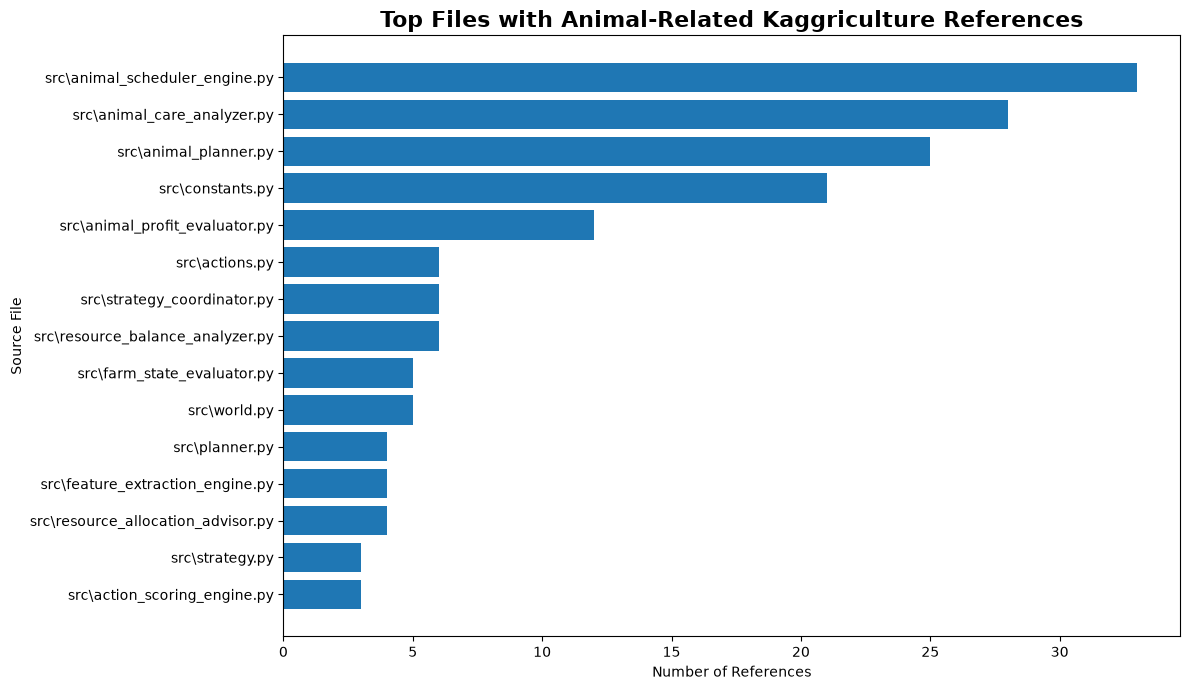

In [26]:
# ============================================================
# 📊 TOP FILES WITH ANIMAL-RELATED REFERENCES
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(
    top_animal_files["File"][::-1],
    top_animal_files["References"][::-1]
)

ax.set_title(
    "Top Files with Animal-Related Kaggriculture References",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Number of References")
ax.set_ylabel("Source File")

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# 📈 5E. CUMULATIVE ANIMAL REVENUE — 30 DAYS
# ============================================================

animal_params = {
    "Goose": {
        "product": "Egg",
        "purchase_cost": 300,
        "selling_price": 50,
        "first_yield_day": 4,
        "production_interval": 1,
    },
    "Cow": {
        "product": "Milk",
        "purchase_cost": 400,
        "selling_price": 160,
        "first_yield_day": 8,
        "production_interval": 2,
    },
    "Sheep": {
        "product": "Wool",
        "purchase_cost": 500,
        "selling_price": 200,
        "first_yield_day": 6,
        "production_interval": 3,
    },
}

days = range(1, 31)

revenue_records = []

for animal, params in animal_params.items():

    for day in days:

        # Number of production events up to this day
        if day >= params["first_yield_day"]:
            production_count = (
                (day - params["first_yield_day"])
                // params["production_interval"]
            ) + 1
        else:
            production_count = 0

        revenue = (
            production_count
            * params["selling_price"]
        )

        revenue_records.append({
            "Day": day,
            "Animal": animal,
            "Production": production_count,
            "Cumulative Revenue": revenue,
        })


animal_revenue = pd.DataFrame(revenue_records)

display(animal_revenue.head(10))

,Day,Animal,Production,Cumulative Revenue
0,1,Goose,0,0
1,2,Goose,0,0
2,3,Goose,0,0
3,4,Goose,1,50
4,5,Goose,2,100
5,6,Goose,3,150
6,7,Goose,4,200
7,8,Goose,5,250
8,9,Goose,6,300
9,10,Goose,7,350


C:\Users\kambar\AppData\Local\Temp\ipykernel_15816\446652502.py:34: UserWarning: Glyph 128004 (\N{COW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\kambar\Kaggriculture-AI-Agent\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128004 (\N{COW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


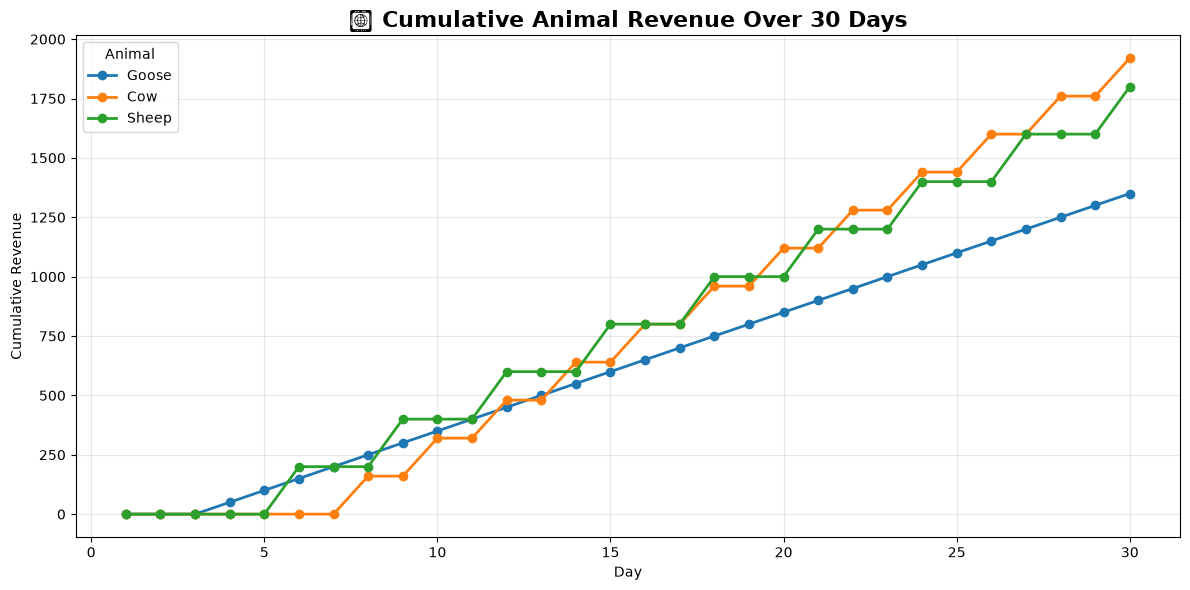

In [28]:
# ============================================================
# 📊 CUMULATIVE REVENUE VISUALIZATION
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

for animal in animal_params:

    data = animal_revenue[
        animal_revenue["Animal"] == animal
    ]

    ax.plot(
        data["Day"],
        data["Cumulative Revenue"],
        marker="o",
        linewidth=2,
        label=animal,
    )

ax.set_title(
    "🐄 Cumulative Animal Revenue Over 30 Days",
    fontsize=16,
    fontweight="bold",
)

ax.set_xlabel("Day")
ax.set_ylabel("Cumulative Revenue")

ax.legend(title="Animal")

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# 🌾 5F. ANIMAL FEED ECONOMICS
# ============================================================

print("🌾 KAGGRICULTURE AI AGENT — ANIMAL FEED ECONOMICS")
print("=" * 70)

animal_feed = pd.DataFrame({
    "Animal": ["Goose", "Cow", "Sheep"],
    "Product": ["Egg", "Milk", "Wool"],
    "Purchase Cost": [300, 400, 500],
    "Product Price": [50, 160, 200],
    "Production Interval": [1, 2, 3],
    "First Yield Day": [4, 8, 6],
})

# Kaggriculture rule:
# Each surviving animal must be fed with wheat every day.
season_days = 30

animal_feed["Wheat Required"] = season_days

# Use the current wheat market price if available.
wheat_price = None

try:
    wheat_price = obs["market"]["prices"]["WHEAT"]
except (NameError, KeyError, TypeError):
    pass

if wheat_price is None:
    print("⚠️ Current market wheat price is unavailable.")
    print("Using the documented base wheat price of $25.")
    wheat_price = 25

animal_feed["Feed Cost"] = (
    animal_feed["Wheat Required"] * wheat_price
)

animal_feed["Feed-Adjusted Cost"] = (
    animal_feed["Purchase Cost"] +
    animal_feed["Feed Cost"]
)

display(animal_feed)

🌾 KAGGRICULTURE AI AGENT — ANIMAL FEED ECONOMICS
⚠️ Current market wheat price is unavailable.
Using the documented base wheat price of $25.


,Animal,Product,Purchase Cost,Product Price,Production Interval,First Yield Day,Wheat Required,Feed Cost,Feed-Adjusted Cost
0,Goose,Egg,300,50,1,4,30,750,1050
1,Cow,Milk,400,160,2,8,30,750,1150
2,Sheep,Wool,500,200,3,6,30,750,1250


C:\Users\kambar\AppData\Local\Temp\ipykernel_15816\4259229936.py:38: UserWarning: Glyph 128004 (\N{COW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\kambar\Kaggriculture-AI-Agent\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128004 (\N{COW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


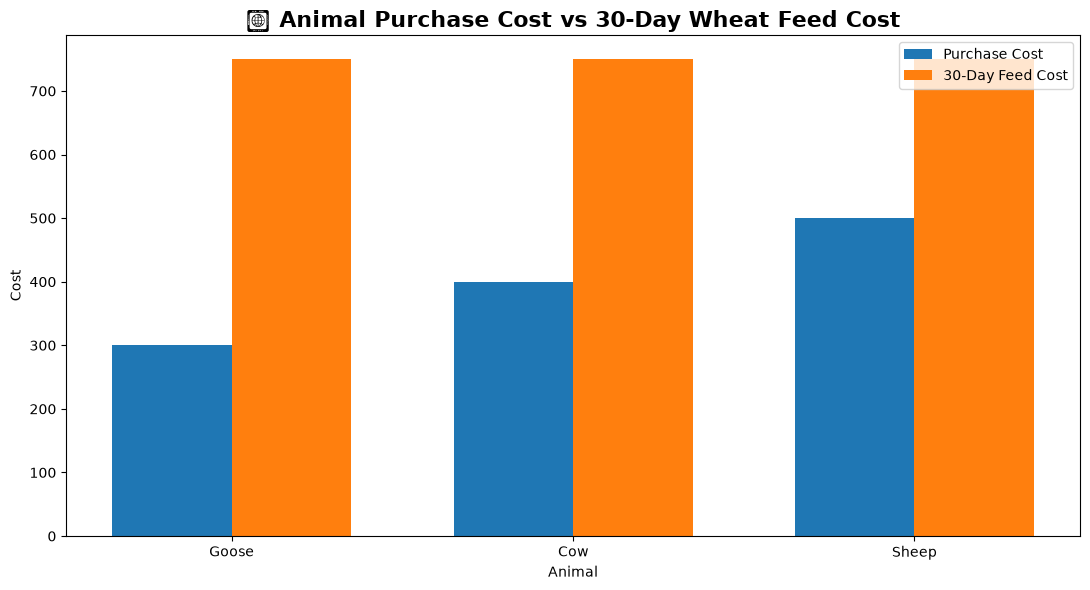

In [30]:
# ============================================================
# 📊 ANIMAL PURCHASE + FEED COST
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(animal_feed))
width = 0.35

ax.bar(
    x - width / 2,
    animal_feed["Purchase Cost"],
    width,
    label="Purchase Cost"
)

ax.bar(
    x + width / 2,
    animal_feed["Feed Cost"],
    width,
    label="30-Day Feed Cost"
)

ax.set_title(
    "🐄 Animal Purchase Cost vs 30-Day Wheat Feed Cost",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Animal")
ax.set_ylabel("Cost")

ax.set_xticks(x)
ax.set_xticklabels(animal_feed["Animal"])

ax.legend()

plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# ❤️ 5G. ANIMAL CARE BONUS ANALYSIS
# ============================================================

print("❤️ KAGGRICULTURE AI AGENT — ANIMAL CARE BONUS")
print("=" * 70)

animal_care_params = {
    "Goose": {
        "first_yield_day": 4,
        "interval": 1,
        "base_price": 50,
    },
    "Cow": {
        "first_yield_day": 8,
        "interval": 2,
        "base_price": 160,
    },
    "Sheep": {
        "first_yield_day": 6,
        "interval": 3,
        "base_price": 200,
    },
}

care_records = []

for animal, params in animal_care_params.items():

    pending_bonus = 0
    total_production = 0
    total_revenue = 0

    for day in range(1, 31):

        # Fed + cared every day → bank one CARE bonus
        pending_bonus += 1

        # Scheduled production
        if day >= params["first_yield_day"]:
            if (
                (day - params["first_yield_day"])
                % params["interval"] == 0
            ):

                # Base production + all banked CARE bonus
                production = 1 + pending_bonus

                total_production += production

                total_revenue += (
                    production *
                    params["base_price"]
                )

                # CARE bonus is reset after production
                pending_bonus = 0

    care_records.append({
        "Animal": animal,
        "Production With CARE": total_production,
        "Revenue With CARE": total_revenue,
    })

animal_care_df = pd.DataFrame(care_records)

display(animal_care_df)

❤️ KAGGRICULTURE AI AGENT — ANIMAL CARE BONUS


,Animal,Production With CARE,Revenue With CARE
0,Goose,57,2850
1,Cow,42,6720
2,Sheep,39,7800


In [32]:
# ============================================================
# 📊 CARE VS NO-CARE COMPARISON
# ============================================================

comparison_records = []

for animal, params in animal_care_params.items():

    no_care_production = 0
    care_production = 0

    pending_bonus = 0

    for day in range(1, 31):

        # CARE every day
        pending_bonus += 1

        if day >= params["first_yield_day"]:

            if (
                (day - params["first_yield_day"])
                % params["interval"] == 0
            ):

                # Without CARE
                no_care_production += 1

                # With CARE
                care_production += (
                    1 + pending_bonus
                )

                pending_bonus = 0

    price = params["base_price"]

    no_care_revenue = (
        no_care_production * price
    )

    care_revenue = (
        care_production * price
    )

    comparison_records.append({
        "Animal": animal,
        "No CARE Production": no_care_production,
        "CARE Production": care_production,
        "Additional Production": (
            care_production -
            no_care_production
        ),
        "No CARE Revenue": no_care_revenue,
        "CARE Revenue": care_revenue,
        "Additional Revenue": (
            care_revenue -
            no_care_revenue
        ),
    })

care_comparison = pd.DataFrame(
    comparison_records
)

display(care_comparison)

,Animal,No CARE Production,CARE Production,Additional Production,No CARE Revenue,CARE Revenue,Additional Revenue
0,Goose,27,57,30,1350,2850,1500
1,Cow,12,42,30,1920,6720,4800
2,Sheep,9,39,30,1800,7800,6000


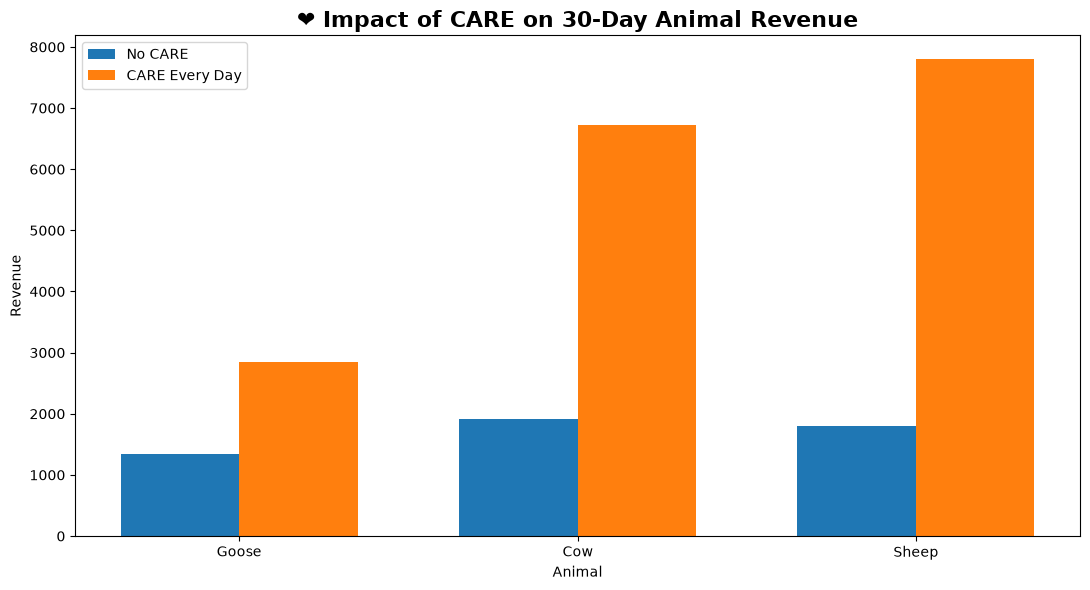

In [33]:
# ============================================================
# 📈 CARE IMPACT ON REVENUE
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(care_comparison))
width = 0.35

ax.bar(
    x - width / 2,
    care_comparison["No CARE Revenue"],
    width,
    label="No CARE"
)

ax.bar(
    x + width / 2,
    care_comparison["CARE Revenue"],
    width,
    label="CARE Every Day"
)

ax.set_title(
    "❤️ Impact of CARE on 30-Day Animal Revenue",
    fontsize=16,
    fontweight="bold",
)

ax.set_xlabel("Animal")
ax.set_ylabel("Revenue")

ax.set_xticks(x)
ax.set_xticklabels(
    care_comparison["Animal"]
)

ax.legend()

plt.tight_layout()
plt.show()

### 💰 5H. Profitability Sensitivity to Wheat Price

This is more useful than using only one wheat price because it answers:

At what wheat price does each animal remain profitable?

In [34]:
# ============================================================
# 💰 5H. ANIMAL PROFITABILITY — WHEAT PRICE SENSITIVITY
# ============================================================

print("💰 KAGGRICULTURE AI AGENT — ANIMAL PROFITABILITY")
print("=" * 70)

animal_economics = {
    "Goose": {
        "purchase_cost": 300,
        "product_price": 50,
        "first_yield_day": 4,
        "interval": 1,
    },
    "Cow": {
        "purchase_cost": 400,
        "product_price": 160,
        "first_yield_day": 8,
        "interval": 2,
    },
    "Sheep": {
        "purchase_cost": 500,
        "product_price": 200,
        "first_yield_day": 6,
        "interval": 3,
    },
}

season_days = 30

records = []

for animal, p in animal_economics.items():

    # Number of scheduled production events
    if season_days >= p["first_yield_day"]:
        production_events = (
            (season_days - p["first_yield_day"])
            // p["interval"]
        ) + 1
    else:
        production_events = 0

    gross_revenue = (
        production_events *
        p["product_price"]
    )

    for wheat_price in [10, 15, 20, 25, 30, 35, 40, 50]:

        wheat_required = season_days

        feed_cost = (
            wheat_required *
            wheat_price
        )

        net_profit = (
            gross_revenue
            - p["purchase_cost"]
            - feed_cost
        )

        records.append({
            "Animal": animal,
            "Wheat Price": wheat_price,
            "Production Events": production_events,
            "Gross Revenue": gross_revenue,
            "Purchase Cost": p["purchase_cost"],
            "Feed Cost": feed_cost,
            "Net Profit": net_profit,
        })

profitability_sensitivity = pd.DataFrame(records)

display(profitability_sensitivity)

💰 KAGGRICULTURE AI AGENT — ANIMAL PROFITABILITY


,Animal,Wheat Price,Production Events,Gross Revenue,Purchase Cost,Feed Cost,Net Profit
0,Goose,10,27,1350,300,300,750
1,Goose,15,27,1350,300,450,600
2,Goose,20,27,1350,300,600,450
3,Goose,25,27,1350,300,750,300
4,Goose,30,27,1350,300,900,150
5,Goose,35,27,1350,300,1050,0
6,Goose,40,27,1350,300,1200,-150
7,Goose,50,27,1350,300,1500,-450
8,Cow,10,12,1920,400,300,1220
9,Cow,15,12,1920,400,450,1070


## 📊 Profitability as wheat price changes

C:\Users\kambar\AppData\Local\Temp\ipykernel_15816\3126622047.py:40: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\kambar\Kaggriculture-AI-Agent\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


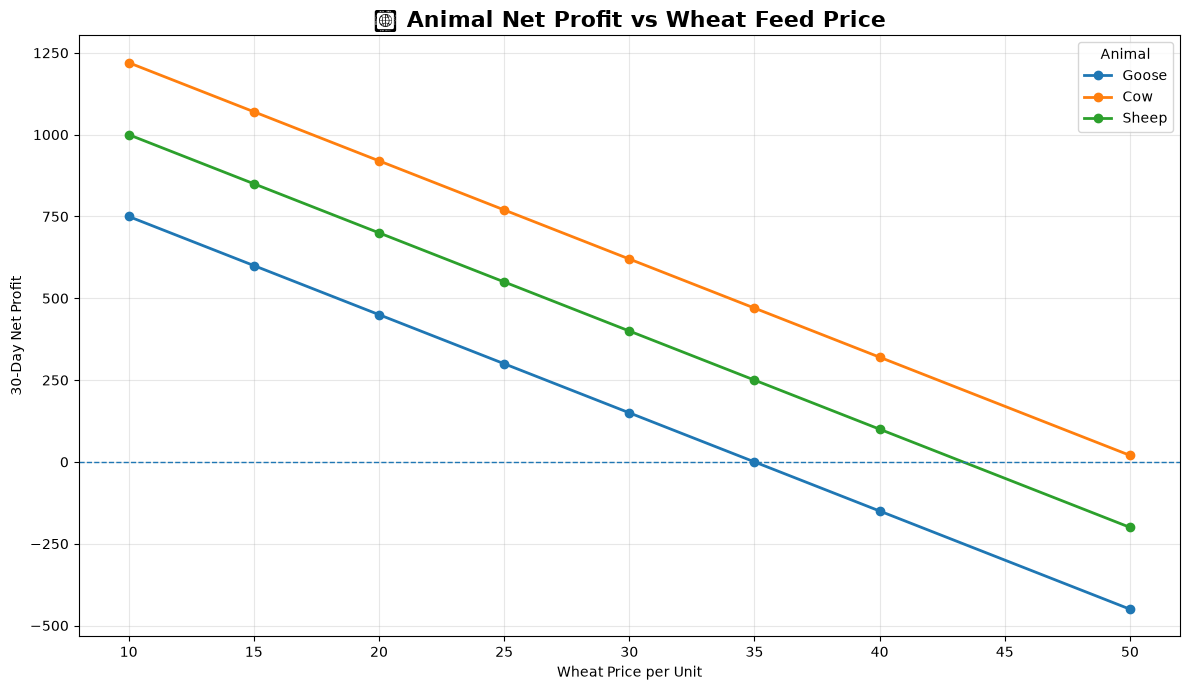

In [35]:
# ============================================================
# 📈 5H — PROFITABILITY SENSITIVITY VISUALIZATION
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

for animal in animal_economics:

    data = profitability_sensitivity[
        profitability_sensitivity["Animal"] == animal
    ]

    ax.plot(
        data["Wheat Price"],
        data["Net Profit"],
        marker="o",
        linewidth=2,
        label=animal,
    )

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "💰 Animal Net Profit vs Wheat Feed Price",
    fontsize=16,
    fontweight="bold",
)

ax.set_xlabel("Wheat Price per Unit")
ax.set_ylabel("30-Day Net Profit")

ax.legend(title="Animal")

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 🔎 Break-even wheat price

We can make the analysis even better by calculating the approximate wheat price at which each animal reaches $0 net profit:

In [36]:
# ============================================================
# 🎯 5H — BREAK-EVEN WHEAT PRICE
# ============================================================

break_even_records = []

for animal, p in animal_economics.items():

    if season_days >= p["first_yield_day"]:
        production_events = (
            (season_days - p["first_yield_day"])
            // p["interval"]
        ) + 1
    else:
        production_events = 0

    gross_revenue = (
        production_events *
        p["product_price"]
    )

    # Revenue - purchase cost - (30 * wheat_price) = 0
    break_even_wheat_price = (
        gross_revenue -
        p["purchase_cost"]
    ) / season_days

    break_even_records.append({
        "Animal": animal,
        "Production Events": production_events,
        "Gross Revenue": gross_revenue,
        "Purchase Cost": p["purchase_cost"],
        "Break-Even Wheat Price": break_even_wheat_price,
    })

break_even_df = pd.DataFrame(
    break_even_records
)

display(break_even_df)

,Animal,Production Events,Gross Revenue,Purchase Cost,Break-Even Wheat Price
0,Goose,27,1350,300,35.000000
1,Cow,12,1920,400,50.666667
2,Sheep,9,1800,500,43.333333


## 🧠 Interpretation

This gives you a much stronger conclusion for the notebook:

- Goose produces frequently but has a relatively low-value egg.
- Cow has a higher purchase cost and later first production, but milk has a much higher base selling price.
- Sheep has the highest product value among the three, but production occurs only every three days.
- Wheat price matters directly because each animal requires feeding every day.
- The actual competition can differ because Kaggriculture's market price is dynamic.

And importantly, CARE should be treated as a separate production-management effect, not mixed into this baseline calculation. The README says CARE bonuses are banked and applied to the next scheduled production, so we'll add that after establishing this clean baseline.

## 🐄 5I. Final Animal Economics Dashboard

In [37]:
# ============================================================
# 🐄 5I. FINAL ANIMAL ECONOMICS DASHBOARD
# ============================================================

print("🐄 KAGGRICULTURE AI AGENT — FINAL ANIMAL ECONOMICS")
print("=" * 70)

# Kaggriculture animal parameters from README
animal_dashboard = pd.DataFrame({
    "Animal": ["Goose", "Cow", "Sheep"],
    "Product": ["Egg", "Milk", "Wool"],
    "Purchase Cost": [300, 400, 500],
    "Selling Price": [50, 160, 200],
    "First Yield Day": [4, 8, 6],
    "Production Interval": [1, 2, 3],
})

SEASON_DAYS = 30
WHEAT_PRICE = 25  # documented base wheat price

# ------------------------------------------------------------
# Production events during the 30-day season
# ------------------------------------------------------------

animal_dashboard["Production Events"] = (
    (
        SEASON_DAYS -
        animal_dashboard["First Yield Day"]
    )
    // animal_dashboard["Production Interval"]
) + 1

# ------------------------------------------------------------
# Gross revenue
# ------------------------------------------------------------

animal_dashboard["Gross Revenue"] = (
    animal_dashboard["Production Events"] *
    animal_dashboard["Selling Price"]
)

# ------------------------------------------------------------
# Feed economics
# ------------------------------------------------------------

animal_dashboard["Wheat Required"] = SEASON_DAYS

animal_dashboard["Feed Cost"] = (
    animal_dashboard["Wheat Required"] *
    WHEAT_PRICE
)

# ------------------------------------------------------------
# Net profit before CARE
# ------------------------------------------------------------

animal_dashboard["Total Investment"] = (
    animal_dashboard["Purchase Cost"] +
    animal_dashboard["Feed Cost"]
)

animal_dashboard["Net Profit"] = (
    animal_dashboard["Gross Revenue"] -
    animal_dashboard["Total Investment"]
)

# ------------------------------------------------------------
# ROI
# ------------------------------------------------------------

animal_dashboard["ROI (%)"] = (
    animal_dashboard["Net Profit"] /
    animal_dashboard["Total Investment"]
) * 100

display(
    animal_dashboard.style.format({
        "Purchase Cost": "${:,.0f}",
        "Selling Price": "${:,.0f}",
        "Gross Revenue": "${:,.0f}",
        "Feed Cost": "${:,.0f}",
        "Total Investment": "${:,.0f}",
        "Net Profit": "${:,.0f}",
        "ROI (%)": "{:.1f}%",
    })
)

🐄 KAGGRICULTURE AI AGENT — FINAL ANIMAL ECONOMICS


,Animal,Product,Purchase Cost,Selling Price,First Yield Day,Production Interval,Production Events,Gross Revenue,Wheat Required,Feed Cost,Total Investment,Net Profit,ROI (%)
0,Goose,Egg,$300,$50,4,1,27,"$1,350",30,$750,"$1,050",$300,28.6%
1,Cow,Milk,$400,$160,8,2,12,"$1,920",30,$750,"$1,150",$770,67.0%
2,Sheep,Wool,$500,$200,6,3,9,"$1,800",30,$750,"$1,250",$550,44.0%


## 📊 Final profitability comparison

C:\Users\kambar\AppData\Local\Temp\ipykernel_15816\908090225.py:45: UserWarning: Glyph 128004 (\N{COW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\kambar\Kaggriculture-AI-Agent\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128004 (\N{COW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


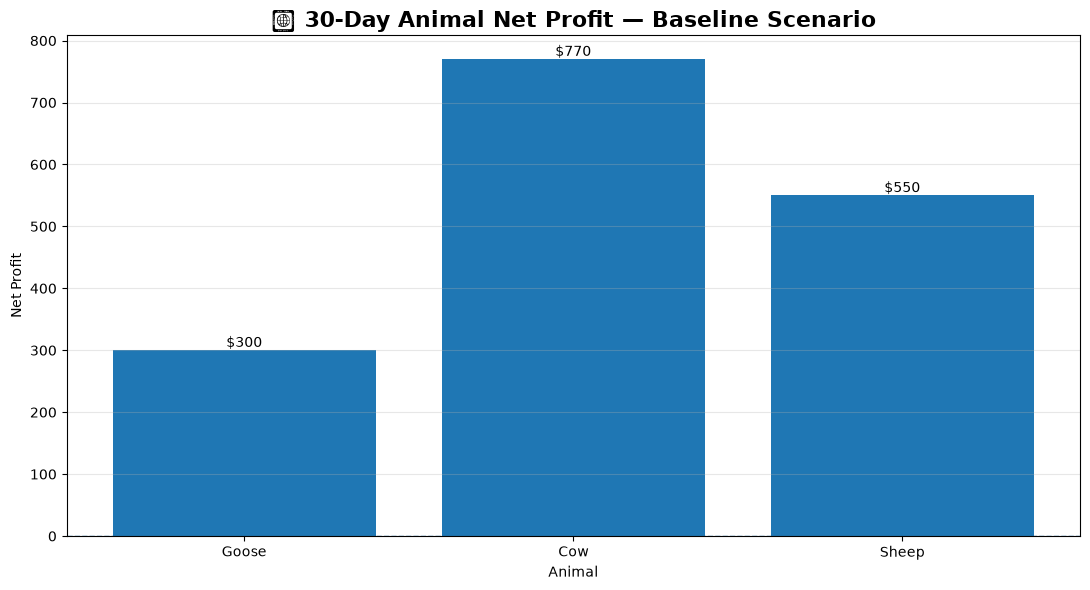

In [38]:
# ============================================================
# 📊 FINAL ANIMAL PROFITABILITY
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    animal_dashboard["Animal"],
    animal_dashboard["Net Profit"]
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "🐄 30-Day Animal Net Profit — Baseline Scenario",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Animal")
ax.set_ylabel("Net Profit")

# Add values above bars
for bar in bars:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom"
    )

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 💡 8. Key Insights

### 🌾 Farming Economics
- Compare crops using gross margin and return per production turn.
- Higher selling price does not necessarily mean better efficiency.
- Production-cycle length is an important factor in evaluating crops.

### 🤖 Agent Architecture
- The repository structure provides the foundation for agent-based
  decision-making.
- Source inspection connects the notebook analysis to the actual
  implementation.

### 🎮 Simulation
- Simulation performance should only be discussed when recorded
  simulation results are available.
- Hard-coded reward values are excluded from performance claims.

### 🏁 Conclusion

The Kaggriculture AI Agent combines farming economics, resource
management, and adaptive decision-making within a turn-based
simulation environment.

The notebook separates **game-rule analysis** from **empirical
simulation results**, ensuring that economic calculations are not
mistaken for observed agent performance.